In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import matplotlib.transforms as mtx
import numpy as np
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path


In [5]:
rows=["LeBlanc et al. (2021)","VEDAI (2015)","COWC (2016)","SOD-YOLO (2024)","Gliaubiute (2023)","This project"]
cols=["Fine res.\n(~25 cm)","UK\ndata","Dense /\noccluded","Nadir\ntop-down","Detection-\nbased","Det. & count\nseparate","Occupancy\nestimation"]
# 1 = yes, 0 = no, 0.5 = partial/indirect
M=[
 [0,1,1,1,1,0,1],   # LeBlanc
 [1,0,0,1,1,0,0],   # VEDAI
 [1,0,1,1,0.5,0,0], # COWC
 [1,0,1,0,1,0,0],   # SOD-YOLO
 [1,0,0,1,1,0,0],   # Gliaubiute
 [1,1,1,1,1,1,1], # This project
]
face={1:"#d6efdd",0:"#f7d9d6",0.5:"#fbe7c6"}
glyph={1:"✓",0:"✗",0.5:"~"}
gcol={1:"#1e7d3c",0:"#b23a30",0.5:"#9a6a12"}

nR,nC=len(rows),len(cols)
fig,ax=plt.subplots(figsize=(12.5,6.4),dpi=300)
ax.set_xlim(-0.02,nC+ (3.2)); ax.set_ylim(0,nR+1.6); ax.axis("off")
LBL=3.2  # width reserved for row labels (in cell units, to the left)
# We'll place label area from x=-LBL.. actually shift: labels left of x=0
ax.set_xlim(-LBL,nC); 
# column headers
for j,c in enumerate(cols):
    ax.text(j+0.5,nR+0.35,c,ha="center",va="center",fontsize=9,fontweight="bold")
# rows (draw top-to-bottom: row 0 at top)
for i,r in enumerate(rows):
    yy=nR-1-i  # top row highest y
    proj=(r=="This project")
    ax.text(-0.15,yy+0.5,r,ha="right",va="center",fontsize=10,
            fontweight="bold" if proj else "normal",
            color="#111" if proj else "#222")
    for j in range(nC):
        v=M[i][j]
        ax.add_patch(Rectangle((j+0.03,yy+0.05),0.94,0.9,fc=face[v],ec="white",lw=1.4))
        ax.text(j+0.5,yy+0.5,glyph[v],ha="center",va="center",fontsize=15,fontweight="bold",color=gcol[v])
# highlight This-project row with an outline + separating rule
ax.add_patch(Rectangle((-LBL+0.05,0.02),LBL-0.1+nC,0.96,fill=False,ec="#3a6ea5",lw=2.4))
ax.plot([-LBL+0.05,nC],[1.02,1.02],color="#999",lw=1.0)

ax.text((nC-LBL)/2, nR+1.15,"Positioning of prior work against the niche this project addresses",
        ha="center",fontsize=13,fontweight="bold")
ax.text((nC-LBL)/2,-0.55,"✓ addressed    ✗ not addressed    ~ partial / indirect    "
        "(assignments follow the synthesis in this chapter)",
        ha="center",fontsize=8.6,color="#555")
fig.savefig("fig_gap_matrix.png",bbox_inches="tight"); plt.close(fig); print("saved fig_gap_matrix.png")


saved fig_gap_matrix.png


In [6]:


GREY="#8a8f96"; RED="#d1352b"; GREEN="#2e9e57"; BLUE="#3a6ea5"

def car(ax,cx,cy,L,W,angle=18,color=GREY):
    r=Rectangle((cx-L/2,cy-W/2),L,W,fc=color,ec="#42474d",lw=1.0)
    r.set_transform(mtx.Affine2D().rotate_deg_around(cx,cy,angle)+ax.transData); ax.add_patch(r)
    w=Rectangle((cx-L*0.13,cy-W/2),L*0.26,W,fc="#c9ccd0",ec="none")
    w.set_transform(mtx.Affine2D().rotate_deg_around(cx,cy,angle)+ax.transData); ax.add_patch(w)

def grid(ax):
    for g in range(0,11,2):
        ax.axhline(g,color="#e3e6ea",lw=0.8,zorder=0); ax.axvline(g,color="#e3e6ea",lw=0.8,zorder=0)

fig,axs=plt.subplots(1,2,figsize=(13.5,6.2),dpi=300)

# ---- LEFT: anchor-based ----
ax=axs[0]; ax.set_xlim(0,10); ax.set_ylim(0,10); ax.set_aspect("equal"); ax.axis("off"); grid(ax)
ax.set_title("Anchor-based  (e.g. Faster R-CNN)",fontsize=13,fontweight="bold",pad=12)
cx,cy=5,5.2
# oversized preset anchors of different aspect ratios, all centred on the cell
anchors=[(6.4,6.4,"#3a6ea5"),(7.6,3.8,"#8a5cc0"),(3.8,6.4,"#c07a1c")]
for w,h,c in anchors:
    ax.add_patch(Rectangle((cx-w/2,cy-h/2),w,h,fill=False,ec=c,lw=2.0,ls=(0,(5,3))))
car(ax,cx,cy,1.5,0.6,18)
ax.add_patch(Circle((cx,cy),0.10,fc="#111",zorder=6))
ax.text(cx,9.35,"Preset anchor boxes (fixed sizes & aspect ratios),",ha="center",fontsize=9.5)
ax.text(cx,8.95,"sized for everyday objects",ha="center",fontsize=9.5)
ax.text(cx,0.75,"tiny car overlaps every anchor only weakly",ha="center",fontsize=9.5,color=RED)
ax.text(cx,0.35,"low IoU  →  hard to match, priors must be re-tuned",ha="center",fontsize=9.5,color=RED,fontweight="bold")

# ---- RIGHT: anchor-free ----
ax=axs[1]; ax.set_xlim(0,10); ax.set_ylim(0,10); ax.set_aspect("equal"); ax.axis("off"); grid(ax)
ax.set_title("Anchor-free  (YOLOv8)",fontsize=13,fontweight="bold",pad=12)
cx,cy=5,5.2
car(ax,cx,cy,1.5,0.6,18)
ax.add_patch(Circle((cx,cy),0.16,fc=RED,ec="white",lw=1,zorder=6))
# direct size regression arrows (w and h) from centre
for dx,dy,lab in [(1.35,0,"w"),(-1.35,0,""),(0,0.85,"h"),(0,-0.85,"")]:
    ax.add_patch(FancyArrowPatch((cx,cy),(cx+dx,cy+dy),arrowstyle="-|>",mutation_scale=13,color=GREEN,lw=2.0))
    if lab: ax.text(cx+dx*1.18,cy+dy*1.18+ (0.25 if dy else 0.28),lab,fontsize=12,color=GREEN,fontweight="bold",ha="center")
ax.add_patch(Circle((cx,cy),0.16,fill=False,ec="#111",lw=0.8,zorder=7))
ax.text(cx,9.35,"Predict object centre directly, then regress",ha="center",fontsize=9.5)
ax.text(cx,8.95,"box width & height from that point",ha="center",fontsize=9.5)
ax.text(cx,0.75,"no template matching, no anchor tuning",ha="center",fontsize=9.5,color=GREEN)
ax.text(cx,0.35,"fewer candidate boxes  →  faster suppression",ha="center",fontsize=9.5,color=GREEN,fontweight="bold")

fig.suptitle("Why anchor-free suits tiny aerial vehicles",fontsize=14,y=1.02)
fig.tight_layout(); fig.savefig("fig_anchor.png",bbox_inches="tight"); plt.close(fig); print("saved fig_anchor.png")


saved fig_anchor.png


In [7]:
GREEN="#2e9e57"; RED="#d1352b"; GREY="#8a8f96"; BLUE="#3a6ea5"; ORANGE="#e8862a"

def car(ax,cx,cy,L,W,angle,color=GREY):
    r=Rectangle((cx-L/2,cy-W/2),L,W,fc=color,ec="#4a4f55",lw=1.0,alpha=0.95)
    t=mtx.Affine2D().rotate_deg_around(cx,cy,angle)+ax.transData
    r.set_transform(t); ax.add_patch(r)
    # windscreen hint
    w=Rectangle((cx-L*0.12,cy-W/2),L*0.24,W,fc="#c9ccd0",ec="none",alpha=0.9)
    w.set_transform(t); ax.add_patch(w)


# =================== Figure: box conversion ===================
fig,axs=plt.subplots(1,2,figsize=(12,5.4),dpi=300)

# panel (a): point -> square box
ax=axs[0]; ax.set_xlim(0,10); ax.set_ylim(0,10); ax.set_aspect("equal"); ax.axis("off")
ax.add_patch(Rectangle((0.5,0.5),9,9,fc="#f3f4f6",ec="#cfd3d8"))
ax.text(5,9.9,"(a)  Centre point  ->  fixed square box",ha="center",va="top",fontsize=12,fontweight="bold")
car(ax,5,5,3.4,1.35,28)
ax.add_patch(Circle((5,5),0.16,fc=RED,ec="white",lw=1,zorder=5))
ax.add_patch(Rectangle((5-1.9,5-1.9),3.8,3.8,fill=False,ec=GREEN,lw=2.2))
ax.annotate("centre-point label",xy=(5,5),xytext=(6.7,2.2),fontsize=9.5,color=RED,
            arrowprops=dict(arrowstyle="->",color=RED,lw=1.3),ha="center")
ax.text(5,8.3,"14x14 px square, sized to the\ncar's longest dimension",ha="center",fontsize=9.5,color=GREEN)

# panel (b): rotation invariance
ax=axs[1]; ax.set_xlim(0,16); ax.set_ylim(0,10); ax.set_aspect("equal"); ax.axis("off")
ax.text(8,9.9,"(b)  One square covers every heading; a tight rectangle does not",
        ha="center",va="top",fontsize=12,fontweight="bold")
for i,ang in enumerate([0,45,90]):
    cx=3+i*5; cy=5.2
    car(ax,cx,cy,3.4,1.35,ang)
    ax.add_patch(Rectangle((cx-1.9,cy-1.9),3.8,3.8,fill=False,ec=GREEN,lw=2.2))
    # axis-aligned tight rect sized for 0deg (L x W): fails when rotated
    ax.add_patch(Rectangle((cx-1.7,cy-0.7),3.4,1.35,fill=False,ec=RED,lw=1.6,ls="--"))
    ax.text(cx,2.5,f"{ang} deg",ha="center",fontsize=10)
ax.plot([],[],color=GREEN,lw=2.2,label="square box (used)")
ax.plot([],[],color=RED,lw=1.6,ls="--",label="axis-aligned tight box (fits only 0 deg)")
ax.legend(loc="lower center",fontsize=9,ncol=2,frameon=False,bbox_to_anchor=(0.5,-0.02))
fig.tight_layout(); fig.savefig("fig_box_conversion.png",bbox_inches="tight"); plt.close(fig); print("saved fig_box_conversion.png")

saved fig_box_conversion.png


In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

BLUE="#3a6ea5"; ORANGE="#e8862a"; GREEN="#2e9e57"; RED="#d1352b"
fig,ax=plt.subplots(figsize=(11,5.6),dpi=300)
SW=1600; T=640; S=512
ax.set_xlim(-70,1740); ax.set_ylim(0,7.6); ax.axis("off")
ax.text(SW/2,7.4,"Overlapping sliding-window tiling (one row shown)",ha="center",va="top",fontsize=13,fontweight="bold")

# scene strip
ax.add_patch(Rectangle((0,5.7),SW,0.9,fc="#eef1f4",ec="#333",lw=1.8))
ax.text(SW/2,6.15,"scene (single row)",ha="center",va="center",fontsize=10,color="#333")

# overlap shading (behind bars)
for a,b in [(S,T),(SW-T,S+T-(SW-T-S))]:
    pass
# compute tiles: starts 0, 512, edge-flush 960
starts=[(0,BLUE,"tile 1","-"),(S,ORANGE,"tile 2","-"),(SW-T,GREEN,"tile 3  (edge-flush)","--")]
# overlap regions
ax.add_patch(Rectangle((S,0.6),T-S,4.2,fc=RED,ec="none",alpha=0.10))      # 512..640
ax.add_patch(Rectangle((SW-T,0.6),(S+T)-(SW-T),4.2,fc=RED,ec="none",alpha=0.10))  # 960..1152

ys=[4.0,3.0,2.0]
for (x,c,lab,ls),y in zip(starts,ys):
    ax.add_patch(Rectangle((x,y),T,0.75,fc=c,ec=c,lw=1.7,alpha=0.22,ls=ls))
    ax.add_patch(Rectangle((x,y),T,0.75,fill=False,ec=c,lw=1.8,ls=ls))
    ax.text(x+T/2,y+0.37,lab,ha="center",va="center",fontsize=9.5,color=c,fontweight="bold")

# stride arrow (tile1 start -> tile2 start)
ax.add_patch(FancyArrowPatch((0,4.95),(S,4.95),arrowstyle="<|-|>",mutation_scale=13,color="#333",lw=1.4))
ax.text(S/2,5.15,"stride 512",ha="center",fontsize=9.5)
# overlap labels
ax.text((S+T)/2,0.35,"overlap ~128 px (~20%)",ha="center",fontsize=8.6,color=RED)
ax.text((SW-T+S+T)/2,1.35,"overlap",ha="center",fontsize=8,color=RED)
# edge-flush note
ax.annotate("edge-flush tile: last tile is pulled back to the scene border\n(x = scene width - 640) so the far edge is fully covered",
            xy=(SW-30,2.38),xytext=(760,0.75),fontsize=9,color=GREEN,ha="left",
            arrowprops=dict(arrowstyle="->",color=GREEN,lw=1.3))
# scene border guide
for xv in [0,SW]:
    ax.plot([xv,xv],[0.6,6.6],color="#999",ls=":",lw=0.9,zorder=0)
ax.text(SW/2,6.9,"tile size 640 x 640   ·   red bands = overlap regions   ·   dashed = edge-flush tile",
        ha="center",fontsize=9,color="#333")
fig.savefig("fig_tiling.png",bbox_inches="tight"); plt.close(fig); print("saved fig_tiling.png (redesigned)")


saved fig_tiling.png (redesigned)


In [9]:

rows=["COWC\nmodel","VEDAI\nmodel","Combined\nCOWC+VEDAI"]
cols=["COWC (val)","VEDAI (val)"]
# mAP@0.5
m50=np.array([[0.9335,0.2020],
              [0.1684,0.8175],
              [0.9425,0.6959]])
# mAP@0.5:0.95
m95=np.array([[0.4870,0.0447],
              [0.0361,0.4788],
              [0.5162,0.3443]])

fig,ax=plt.subplots(figsize=(7.6,6.2),dpi=300)
im=ax.imshow(m50,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")

ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,fontsize=11)
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows,fontsize=10.5)
ax.set_xlabel("Evaluated on",fontsize=12,labelpad=10)
ax.set_ylabel("Trained on",fontsize=12,labelpad=10)
ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
ax.set_title("Cross-domain generalisation of the source models\n",fontsize=13,fontweight="bold",pad=26)

for i in range(3):
    for j in range(2):
        v=m50[i,j]
        tc="white" if (v>0.72 or v<0.15) else "#111"
        ax.text(j,i-0.11,f"{v:.3f}",ha="center",va="center",fontsize=15,fontweight="bold",color=tc)
        ax.text(j,i+0.20,f"mAP@.5:.95  {m95[i,j]:.3f}",ha="center",va="center",fontsize=8.5,color=tc)

# outline within-domain (specialist on its own set) cells
for (i,j) in [(0,0),(1,1)]:
    ax.add_patch(Rectangle((j-0.5,i-0.5),1,1,fill=False,ec="#111",lw=2.6,ls=(0,(4,2))))

cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.14)
cb.set_label("mAP@0.5",fontsize=11)
ax.text(0.5,2.72,"each cell: mAP@0.5 (large) · mAP@0.5:0.95 (small)",
        ha="center",fontsize=8.6,color="#555",transform=ax.transData)
ax.text(0.5,2.92,"dashed outline = within-domain (specialist evaluated on its own set)",
        ha="center",fontsize=8.6,color="#555",transform=ax.transData)
fig.tight_layout()
fig.savefig("fig_crossdomain.png",bbox_inches="tight"); plt.close(fig)
print("saved fig_crossdomain.png")


saved fig_crossdomain.png


In [10]:
# De-duplicated (site-level, IoU-merge 0.5) TRUTH counts from count_site.py
sites = {
 "UK001":51,"UK002":141,"UK003":17,"UK004":8,"UK005":105,"UK006":17,"UK007":104,"UK008":71,
 "UK009":31,"UK010":39,"UK011":93,"UK012":24,"UK013":93,"UK014":123,"UK015":329,"UK016":100,
 "UK017":63,"UK018":74,"UK019":51,"UK020":51,"UK021":22,"UK022":103,"UK023":146,"UK024":95,
 "UK025":64,"UK026":14,"UK027":52,"UK028":138,"UK029":30,"UK030":139}
cal_train={"UK001","UK010","UK014","UK015","UK018","UK024","UK027","UK029"}
cal_val={"UK009","UK020"}
def cat(s): return "val" if s in cal_val else ("train" if s in cal_train else "test")
colmap={"test":"#9aa0a6","train":"#3a6ea5","val":"#e8862a"}

names=list(sites); vals=[sites[s] for s in names]; colors=[colmap[cat(s)] for s in names]
fig,ax=plt.subplots(figsize=(13,5.4),dpi=300)
ax.bar(range(len(names)),vals,color=colors,edgecolor="white",width=0.8)
for i,v in enumerate(vals):
    ax.text(i,v+4,str(v),ha="center",va="bottom",fontsize=6.8)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=90,fontsize=7.5)
ax.set_ylabel("Annotated cars per site (site-level, de-duplicated)",fontsize=11)
ax.set_ylim(0,360)
ax.set_title("UK retail dataset composition: 30 sites (10 calibration / 20 test)",fontsize=12)
ax.grid(axis="y",alpha=0.25); ax.set_axisbelow(True)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
tr=sum(v for s,v in sites.items() if cat(s)=="train"); va=sum(v for s,v in sites.items() if cat(s)=="val")
te=sum(v for s,v in sites.items() if cat(s)=="test")
handles=[mpatches.Patch(color=colmap["train"],label=f"calibration - train (8 sites, {tr} cars)"),
         mpatches.Patch(color=colmap["val"],  label=f"calibration - val (2: UK009, UK020; {va} cars)"),
         mpatches.Patch(color=colmap["test"], label=f"test (20 sites, {te} cars)")]
ax.legend(handles=handles,fontsize=9,loc="upper right")
fig.tight_layout(); fig.savefig("fig_dataset_composition.png",bbox_inches="tight"); plt.close(fig)
print("saved. totals -> train",tr,"val",va,"test",te,"| all",tr+va+te)


saved. totals -> train 793 val 82 test 1513 | all 2388


In [11]:
ROOT=Path("/sessions/friendly-practical-ride/mnt/carpark-project")
GREEN="#1fe049"

def nboxes(lb):
    try: return sum(1 for l in open(lb) if l.strip())
    except: return 0

def pick(imgdir,lbldir,target):
    imgs=sorted(Path(imgdir).glob("*.png"))+sorted(Path(imgdir).glob("*.jpg"))
    best=None
    for im in imgs:
        lb=Path(lbldir)/(im.stem+".txt"); c=nboxes(lb)
        if c==0: continue
        if best is None or abs(c-target)<abs(best[0]-target): best=(c,im,lb)
    return best

# choose crops
cowc=pick(ROOT/"data/cowc/processed/images/train",ROOT/"data/cowc/processed/labels/train",240)
vedai=pick(ROOT/"data/vedai/processed/images/train",ROOT/"data/vedai/processed/labels/train",5)
uk_png=ROOT/"data/uk_retail/processed/UK030/tiles/UK030_r00000_c00000.png"
uk_txt=ROOT/"data/uk_retail/processed/UK030/tiles/UK030_r00000_c00000.txt"
uk=(nboxes(uk_txt),uk_png,uk_txt)

panels=[("COWC  (US; dense parking)",cowc,"15 cm/px source, resampled to 25 cm"),
        ("VEDAI  (sparse; car parks excluded)",vedai,"12.5 cm/px source, resampled to 25 cm"),
        ("UK retail  (target; dense)",uk,"25 cm/px Getmapping imagery")]

fig,axs=plt.subplots(1,3,figsize=(15,5.7),dpi=300)
for ax,(title,(c,png,txt),sub) in zip(axs,panels):
    im=Image.open(png).convert("RGB"); W,H=im.size
    ax.imshow(im)
    lw=0.6 if c>60 else 1.4
    for line in open(txt):
        p=line.split()
        if len(p)<5: continue
        cx,cy,w,h=[float(x) for x in p[1:5]]
        ax.add_patch(Rectangle(((cx-w/2)*W,(cy-h/2)*H),w*W,h*H,fill=False,edgecolor=GREEN,lw=lw))
    ax.set_title(f"{title}\n{c} cars in this tile",fontsize=11.5,fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(sub,fontsize=8.6,color="#555")
fig.suptitle("Scene-density contrast between the two source datasets and the UK target (all tiles at 25 cm/px)",
             fontsize=13,y=1.02)
fig.tight_layout()
fig.savefig("/sessions/friendly-practical-ride/mnt/outputs/fig_density_contrast.png",bbox_inches="tight")
print("COWC:",cowc[1].name,cowc[0],"| VEDAI:",vedai[1].name,vedai[0],"| UK:",uk[0])


TypeError: cannot unpack non-iterable NoneType object

In [12]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---------- Figure 2: Domain-gap gradient + recovery ----------
labels = ["COWC\n(in-domain)", "VEDAI\n(related sensor)", "UK retail\n(zero-shot)", "UK retail\n(+8-site fine-tune)"]
vals   = [0.9425, 0.6959, 0.5280, 0.8855]
cols   = ["#3a6ea5", "#6b9bd1", "#b5c9e2", "#3ba55d"]

fig, ax = plt.subplots(figsize=(9, 5.6), dpi=300)
bars = ax.bar(range(4), vals, color=cols, edgecolor="white", width=0.62)
for i, v in enumerate(vals):
    ax.text(i, v+0.015, f"{v:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("mAP@0.5", fontsize=11)
ax.set_title("Domain gap and recovery\nSame COWC+VEDAI model across domains (bars 1-3); after UK fine-tune (bar 4)", fontsize=11)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
for s in ["top","right"]: ax.spines[s].set_visible(False)
# annotate the gap and recovery
ax.annotate("", xy=(2, 0.545), xytext=(0, 0.955),
            arrowprops=dict(arrowstyle="->", color="#888", lw=1.3, connectionstyle="arc3,rad=-0.2"))
ax.text(1.0, 0.80, "domain gap\n-0.41", ha="center", fontsize=8.5, color="#555")
ax.annotate("", xy=(3, 0.90), xytext=(2, 0.545),
            arrowprops=dict(arrowstyle="->", color="#3ba55d", lw=1.5, connectionstyle="arc3,rad=-0.3"))
ax.text(2.75, 0.66, "fine-tune\n+0.36", ha="center", fontsize=8.5, color="#2e7d43")
fig.tight_layout(); fig.savefig("fig_domain_gap.png", bbox_inches="tight"); plt.close(fig)
print("saved fig_domain_gap.png")

# ---------- Figure 3: Dataset composition ----------
# per-site annotated car instances (tile-level sums from the assembler)
sites = {
 "UK001":51,"UK002":141,"UK003":17,"UK004":8,"UK005":105,"UK006":17,"UK007":170,"UK008":71,
 "UK009":31,"UK010":39,"UK011":193,"UK012":24,"UK013":93,"UK014":188,"UK015":934,"UK016":194,
 "UK017":63,"UK018":74,"UK019":51,"UK020":51,"UK021":22,"UK022":103,"UK023":268,"UK024":95,
 "UK025":64,"UK026":14,"UK027":52,"UK028":266,"UK029":52,"UK030":273}
cal_train = {"UK001","UK010","UK014","UK015","UK018","UK024","UK027","UK029"}
cal_val   = {"UK009","UK020"}
def cat(s):
    if s in cal_val: return "val"
    if s in cal_train: return "train"
    return "test"
colmap = {"test":"#9aa0a6","train":"#3a6ea5","val":"#e8862a"}

names = list(sites.keys()); vals = [sites[s] for s in names]
colors = [colmap[cat(s)] for s in names]
fig, ax = plt.subplots(figsize=(13, 5.4), dpi=300)
ax.bar(range(len(names)), vals, color=colors, edgecolor="white", width=0.8)
for i,s in enumerate(names):
    ax.text(i, vals[i]+8, str(vals[i]), ha="center", va="bottom", fontsize=6.5, rotation=0)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=7.5)
ax.set_ylabel("Annotated car instances (tile-level)", fontsize=11)
ax.set_title("UK retail dataset composition: 30 sites (10 calibration / 20 test)", fontsize=12)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
handles = [mpatches.Patch(color=colmap["train"], label="calibration - train (8)"),
           mpatches.Patch(color=colmap["val"],   label="calibration - val (2: UK009, UK020)"),
           mpatches.Patch(color=colmap["test"],  label="test (20)")]
ax.legend(handles=handles, fontsize=9, loc="upper right")
fig.tight_layout(); fig.savefig("fig_dataset_composition.png", bbox_inches="tight"); plt.close(fig)
print("saved fig_dataset_composition.png")
print("total cars:", sum(vals), "| test cars:", sum(v for s,v in sites.items() if cat(s)=="test"))


saved fig_domain_gap.png
saved fig_dataset_composition.png
total cars: 3724 | test cars: 2157


In [13]:
ROOT = Path("/sessions/friendly-practical-ride/mnt/carpark-project/data/uk_retail/processed")
# candidate test-site tiles (varied size/layout); use those that exist
cands = [("UK011","UK011_r00000_c00000"),("UK007","UK007_r00000_c00000"),
         ("UK005","UK005_r00000_c00000"),("UK030","UK030_r00000_c00000"),
         ("UK023","UK023_r00000_c00000"),("UK013","UK013_r00000_c00000"),
         ("UK008","UK008_r00000_c00000"),("UK016","UK016_r00000_c00000")]
picks = []
for site, stem in cands:
    png = ROOT/site/"tiles"/f"{stem}.png"; txt = ROOT/site/"tiles"/f"{stem}.txt"
    if png.exists() and txt.exists():
        n = sum(1 for l in txt.read_text().splitlines() if l.strip())
        picks.append((site, stem, png, txt, n))
    if len(picks) == 4: break

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300)
for ax, (site, stem, png, txt, n) in zip(axes.ravel(), picks):
    im = Image.open(png).convert("RGB"); W, H = im.size
    ax.imshow(im)
    for line in txt.read_text().splitlines():
        p = line.split()
        if len(p) < 5: continue
        cx, cy, w, h = [float(x) for x in p[1:5]]
        x0 = (cx-w/2)*W; y0 = (cy-h/2)*H
        ax.add_patch(plt.Rectangle((x0, y0), w*W, h*H, fill=False, edgecolor="#1fe049", lw=1.1))
    ax.set_title(f"{site}  ({n} cars)", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Ground-truth car annotations on UK retail test tiles (25 cm/px, 640x640)", fontsize=13, y=0.98)
leg = mpatches.Patch(edgecolor="#1fe049", facecolor="none", label="car (ground truth)")
fig.legend(handles=[leg], loc="lower center", fontsize=10, ncol=1, frameon=False, bbox_to_anchor=(0.5, 0.005))
fig.tight_layout(rect=[0,0.03,1,0.96])
fig.savefig("/sessions/friendly-practical-ride/mnt/outputs/fig_gt_examples.png", bbox_inches="tight")
print("saved fig_gt_examples.png with tiles:", [p[1] for p in picks])


FileNotFoundError: [Errno 2] No such file or directory: '/sessions/friendly-practical-ride/mnt/outputs/fig_gt_examples.png'

In [14]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Ellipse, FancyBboxPatch
from PIL import Image
import numpy as np
from pathlib import Path

ROOT=Path("/sessions/friendly-practical-ride/mnt/carpark-project")
cands=["UK015/tiles/UK015_r00000_c00000","UK023/tiles/UK023_r00000_c00000",
       "UK030/tiles/UK030_r00000_c00000","UK005/tiles/UK005_r00000_c00000",
       "UK013/tiles/UK013_r00000_c00000","UK011/tiles/UK011_r00000_c00000"]
def load(stem):
    png=ROOT/f"data/uk_retail/processed/{stem}.png"; txt=ROOT/f"data/uk_retail/processed/{stem}.txt"
    if not png.exists(): return None
    im=Image.open(png).convert("RGB"); W,H=im.size
    boxes=[]
    for l in open(txt):
        p=l.split()
        if len(p)>=5:
            cx,cy,w,h=[float(x) for x in p[1:5]]; boxes.append((cx*W,cy*H,w*W,h*H))
    return im,W,H,boxes

WIN=250; best=None
for stem in cands:
    r=load(stem)
    if not r: continue
    im,W,H,boxes=r; arr=np.asarray(im)
    for y0 in range(0,H-WIN,30):
        for x0 in range(0,W-WIN,30):
            sub=arr[y0:y0+WIN,x0:x0+WIN]
            blackfrac=float((sub.sum(2)<40).mean())
            if blackfrac>0.12: continue
            inb=[(cx-x0,cy-y0,w,h) for (cx,cy,w,h) in boxes if x0+14<cx<x0+WIN-14 and y0+14<cy<y0+WIN-14]
            if 5<=len(inb)<=8:
                xs=[b[0] for b in inb]; ys=[b[1] for b in inb]
                spread=(max(xs)-min(xs))+(max(ys)-min(ys))
                score=spread-blackfrac*400
                if best is None or score>best[0]:
                    best=(score,stem,x0,y0,im.crop((x0,y0,x0+WIN,y0+WIN)),inb,blackfrac)
score,stem,x0,y0,crop,inb,bf=best
print("chosen:",stem,x0,y0,"ncars",len(inb),"blackfrac",round(bf,3))

cols=["#e6194B","#3cb44b","#ffe119","#4363d8","#f58231","#911eb4","#42d4f4","#f032e6"]
fig,axs=plt.subplots(1,3,figsize=(14,5.2),dpi=300)
ax=axs[0]; ax.imshow(crop); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("(a) Classification",fontsize=13,fontweight="bold")
ax.add_patch(FancyBboxPatch((6,6),WIN-12,32,boxstyle="round,pad=2",fc="#000000cc",ec="none"))
ax.text(WIN/2,22,"image label:  “contains vehicles”",ha="center",va="center",fontsize=10,color="white",fontweight="bold")
ax.set_xlabel("one label for the whole image",fontsize=9.5,color="#444")
ax=axs[1]; ax.imshow(crop); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("(b) Object detection  ← this project",fontsize=13,fontweight="bold",color="#1a4f8a")
for (cx,cy,w,h) in inb: ax.add_patch(Rectangle((cx-w/2,cy-h/2),w,h,fill=False,edgecolor="#1fe049",lw=2.0))
ax.set_xlabel("one bounding box per vehicle",fontsize=9.5,color="#444")
ax=axs[2]; ax.imshow(crop); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("(c) Instance segmentation",fontsize=13,fontweight="bold")
for i,(cx,cy,w,h) in enumerate(inb):
    ax.add_patch(Ellipse((cx,cy),w*0.98,h*0.98,facecolor=cols[i%len(cols)],alpha=0.55,edgecolor="white",lw=0.8))
ax.set_xlabel("per-pixel mask per vehicle (schematic)",fontsize=9.5,color="#444")
fig.suptitle("Three computer-vision tasks on the same overhead car-park crop",fontsize=13.5,y=1.03)
fig.text(0.5,-0.03,"This project uses detection (b): a box per car is sufficient to count and locate vehicles, "
         "without the pixel-level labelling cost of segmentation (c).",ha="center",fontsize=9.5,color="#555")
fig.tight_layout(); fig.savefig("/sessions/friendly-practical-ride/mnt/outputs/fig_task_hierarchy.png",bbox_inches="tight"); plt.close(fig)
print("saved")


TypeError: cannot unpack non-iterable NoneType object

In [15]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import textwrap

BLUE="#3a6ea5"; LBLUE="#dbe6f2"; GREEN="#3ba55d"; LGREEN="#d8efe0"
GREY="#6d7278"; LGREY="#e9eaec"; ORANGE="#e8862a"; LOR="#fbe6d2"

def box(ax,x,y,w,h,title,sub="",fc=LBLUE,ec=BLUE,tc="#1a1a1a",fs=11,subfs=8.6,wrap=52):
    p=FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.06",
                     fc=fc,ec=ec,lw=1.6); ax.add_patch(p)
    if sub:
        sub_w="\n".join(textwrap.wrap(sub,width=wrap))
        ax.text(x+w/2,y+h*0.72,title,ha="center",va="center",fontsize=fs,fontweight="bold",color=tc)
        ax.text(x+w/2,y+h*0.32,sub_w,ha="center",va="center",fontsize=subfs,color="#333",linespacing=1.25)
    else:
        ax.text(x+w/2,y+h/2,title,ha="center",va="center",fontsize=fs,fontweight="bold",color=tc)

def arrow(ax,x0,y0,x1,y1,color="#555"):
    ax.add_patch(FancyArrowPatch((x0,y0),(x1,y1),arrowstyle="-|>",mutation_scale=16,lw=1.8,color=color))

# ---------------- data-preparation pipeline (vertical) ----------------
fig,ax=plt.subplots(figsize=(8.0,11.4),dpi=300); ax.set_xlim(0,10); ax.set_ylim(0,15.6); ax.axis("off")
W=8.2; X=(10-W)/2
stages=[
 ("Public source scenes","COWC 15 cm/px (centre-point labels)  ·  VEDAI 12.5 cm/px (corner labels)",LGREY,GREY),
 ("Annotation conversion","collapse to single 'vehicle' class; centre points / corners -> axis-aligned square boxes",LBLUE,BLUE),
 ("Resolution matching","bilinear downsample imagery to 25 cm/px; scale label coordinates (masks never resized)",LBLUE,BLUE),
 ("Tiling","cut scenes into 640x640 tiles, stride 512 (~20% overlap) plus edge-flush tiles",LBLUE,BLUE),
 ("Scene-level split","hold out whole scenes for validation (no tile leakage of shared cars)",LBLUE,BLUE),
 ("Fine-tune YOLOv8s","transfer learning from pretrained weights: COWC, VEDAI, and combined models",LGREEN,GREEN),
 ("Evaluate","within-domain and cross-domain; P, R, F1, mAP@0.5, mAP@0.5:0.95",LOR,ORANGE),
]
h=1.6; gap=0.42; y=15.6-h-0.95
for i,(t,s,fc,ec) in enumerate(stages):
    box(ax,X,y,W,h,t,s,fc=fc,ec=ec)
    if i<len(stages)-1: arrow(ax,5,y-0.02,5,y-gap+0.02)
    y-=(h+gap)
ax.text(5,15.55,"Data-preparation and training pipeline (applied to each source dataset)",
        ha="center",va="top",fontsize=12,fontweight="bold")
fig.savefig("fig_pipeline.png",bbox_inches="tight"); plt.close(fig); print("saved fig_pipeline.png")


saved fig_pipeline.png


In [16]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Load the base image
base_square = Image.open("_basecrop.png").convert("RGB")
width, height = base_square.size

# --- OPTION A: Tall Crop (Recommended) ---
# If your "_basecrop.png" is already a square but the original source had more vertical 
# data, you'd load that. If you only have this square image, we can crop a taller 
# aspect ratio from it (making it narrower), which naturally makes it look taller in the strip.
# Let's crop a 3:4 aspect ratio (narrower width, full height):
crop_width = int(width * 0.75) 
left = (width - crop_width) // 2
base = base_square.crop((left, 0, left + crop_width, height))

# If you prefer to physically stretch the square pixels to be taller instead of cropping,
# keep 'base = base_square' and set aspect="auto" in ax.imshow() below.

N = base.size[0]           # New width in px
NATIVE = 15.0
gsds = [15, 25, 30, 50, 100]
disp_w = 225               # Narrower display width to match the taller aspect ratio
disp_h = 300               # Kept height at 300 for a taller look
titles = {15: "15 cm  (COWC native)", 25: "25 cm  ← project target",
          30: "30 cm", 50: "50 cm", 100: "100 cm  (LeBlanc scale)"}

# Increased figure height to match the new rectangular subplots
fig, axs = plt.subplots(1, 5, figsize=(16, 6.0), dpi=300)

for ax, g in zip(axs, gsds):
    px_w = max(1, round(base.size[0] * NATIVE / g))
    px_h = max(1, round(base.size[1] * NATIVE / g))
    
    # Simulate coarser sensor
    down = base.resize((px_w, px_h), Image.BILINEAR)    
    # Display taller rectangular image
    show = down.resize((disp_w, disp_h), Image.NEAREST) 
    
    # Note: If you opted to stretch a square image vertically instead of cropping,
    # you would add: aspect="auto" inside imshow() like this: ax.imshow(show, aspect="auto")
    ax.imshow(show)
    
    carpx = 4.5 / (g / 100.0)                          # 4.5 m car length in px at this GSD
    ax.set_title(titles[g], fontsize=11, fontweight="bold",
                 color="#1a4f8a" if g == 25 else "#111")
    ax.set_xlabel(f"car ≈ {carpx:.0f} px long", fontsize=9.5, color="#444")
    ax.set_xticks([]); ax.set_yticks([])
    if g == 25:
        for s in ax.spines.values(): s.set_edgecolor("#3a6ea5"); s.set_linewidth(3.2)
    else:
        for s in ax.spines.values(): s.set_edgecolor("#cccccc")

# Positioning elements nicely on the taller canvas
fig.suptitle("Effect of ground sampling distance on vehicle detectability "
             "(same car-park bay, simulated by bilinear downsampling from 15 cm COWC)",
             fontsize=12.5, y=0.96)

fig.text(0.5, 0.06, "Detail is stable through 25–30 cm but a car collapses to a few pixels by 100 cm — "
         "the resolution regime of the earlier UK satellite work.",
         ha="center", fontsize=9.5, color="#555")

fig.tight_layout(rect=[0, 0.10, 1, 0.92])
fig.savefig("fig_resolution_strip.png", bbox_inches="tight")
plt.close(fig)
print("saved. px per GSD:", [(g, round(base.size[0] * NATIVE / g)) for g in gsds])

FileNotFoundError: [Errno 2] No such file or directory: '_basecrop.png'

In [17]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BLUE="#3a6ea5"; LBLUE="#dbe6f2"; GREEN="#3ba55d"; LGREEN="#d8efe0"
GREY="#6d7278"; LGREY="#e9eaec"; ORANGE="#e8862a"; LOR="#fbe6d2"

def box(ax,x,y,w,h,title,sub="",fc=LBLUE,ec=BLUE,tc="#1a1a1a",fs=11,subfs=8.6,
        tpos=0.64,spos=0.30):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.06",fc=fc,ec=ec,lw=1.6))
    if sub:
        ax.text(x+w/2,y+h*tpos,title,ha="center",va="center",fontsize=fs,fontweight="bold",color=tc)
        ax.text(x+w/2,y+h*spos,sub,ha="center",va="center",fontsize=subfs,color="#333")
    else:
        ax.text(x+w/2,y+h/2,title,ha="center",va="center",fontsize=fs,fontweight="bold",color=tc)

def arrow(ax,x0,y0,x1,y1,color="#555"):
    ax.add_patch(FancyArrowPatch((x0,y0),(x1,y1),arrowstyle="-|>",mutation_scale=16,lw=1.8,color=color))

fig,ax=plt.subplots(figsize=(11.5,6.8),dpi=300)
ax.set_xlim(0,14.2); ax.set_ylim(-1.0,9.2); ax.axis("off")
ax.text(7.1,9.0,"UK evaluation: three experiments of increasing adaptation",
        ha="center",va="top",fontsize=13,fontweight="bold")
ax.text(7.1,8.35,"all scored on the SAME 20 held-out test sites",
        ha="center",va="top",fontsize=10,color="#444",style="italic")

BX=1.75; BW=2.6            # weights box
DX=6.7;  DW=2.4            # detector box
TX=10.75                   # test box left edge (arrows terminate here)
lanes=[
 ("Baseline","Stock YOLOv8s\n(COCO pretraining)","no adaptation\n(class-agnostic scoring)",GREY,LGREY,6.1),
 ("Transfer","Combined\nCOWC+VEDAI model","applied directly,\nno UK training",BLUE,LBLUE,3.7),
 ("UK-adapt","Combined weights\n+ fine-tune","fine-tuned on\nUK calibration data",GREEN,LGREEN,1.3),
]
for name,wtxt,mid,ec,fc,yy in lanes:
    cy=yy+0.55
    ax.text(0.85,cy,name,ha="center",va="center",fontsize=11,fontweight="bold",color=ec)
    box(ax,BX,yy,BW,1.1,wtxt,fc=fc,ec=ec,fs=9.4)
    ax.text((BX+BW+DX)/2,cy,mid,ha="center",va="center",fontsize=8.6,color="#333")
    arrow(ax,BX+BW,cy,DX,cy,color=ec)
    box(ax,DX,yy,DW,1.1,"UK detector",fc="white",ec=ec,fs=9.6)
    arrow(ax,DX+DW,cy,TX,cy,color=ec)   # -> lands on the tall test box's left edge

# tall shared test box spanning all three lanes
BYy=1.20; BHh=6.10
box(ax,TX,BYy,3.05,BHh,"20 held-out\nUK test sites","P · R · F1\nmAP@0.5\nmAP@0.5:0.95",
    fc="#fff5e9",ec=ORANGE,fs=12,subfs=10,tpos=0.68,spos=0.42)
ax.text(TX+3.05/2,BYy+0.55,"frozen split,\nnever used for training",
        ha="center",va="center",fontsize=8.2,color="#8a6a3a",style="italic")

# UK calibration feeds the uk-adapt weights box
box(ax,BX,-0.15,BW,0.95,"8 calibration sites","fine-tune data",fc="#eef7f0",ec=GREEN,fs=9.0,subfs=7.8)
arrow(ax,BX+BW/2,0.80,BX+BW/2,1.30,color=GREEN)

fig.savefig("fig_three_experiments.png",bbox_inches="tight"); plt.close(fig)
print("saved fig_three_experiments.png")


saved fig_three_experiments.png


In [18]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision", "Recall", "F1", "mAP@0.5", "mAP@0.5:0.95"]
data = {
    "Baseline (stock YOLOv8, class-agnostic)": [0.2570, 0.4655, 0.3311, 0.2673, 0.0913],
    "Transfer (COWC+VEDAI)":                   [0.6945, 0.4828, 0.5696, 0.5280, 0.1459],
    "UK-adapt (fine-tuned, 8 sites)":          [0.8457, 0.8447, 0.8452, 0.8855, 0.3522],
}
colors = ["#9aa0a6", "#4f83cc", "#3ba55d"]

x = np.arange(len(metrics))
w = 0.26
fig, ax = plt.subplots(figsize=(11, 6.2), dpi=300)
for i, (label, vals) in enumerate(data.items()):
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=colors[i], edgecolor="white", linewidth=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_title("UK retail car-park detection: performance across the transfer-learning ladder\n"
             "(scored on 20 held-out test sites; baseline evaluated class-agnostically)", fontsize=11.5)
ax.legend(fontsize=9, loc="upper left", framealpha=0.95)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for s in ["top","right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("fig_metric_ladder.png", bbox_inches="tight")
print("saved")


saved


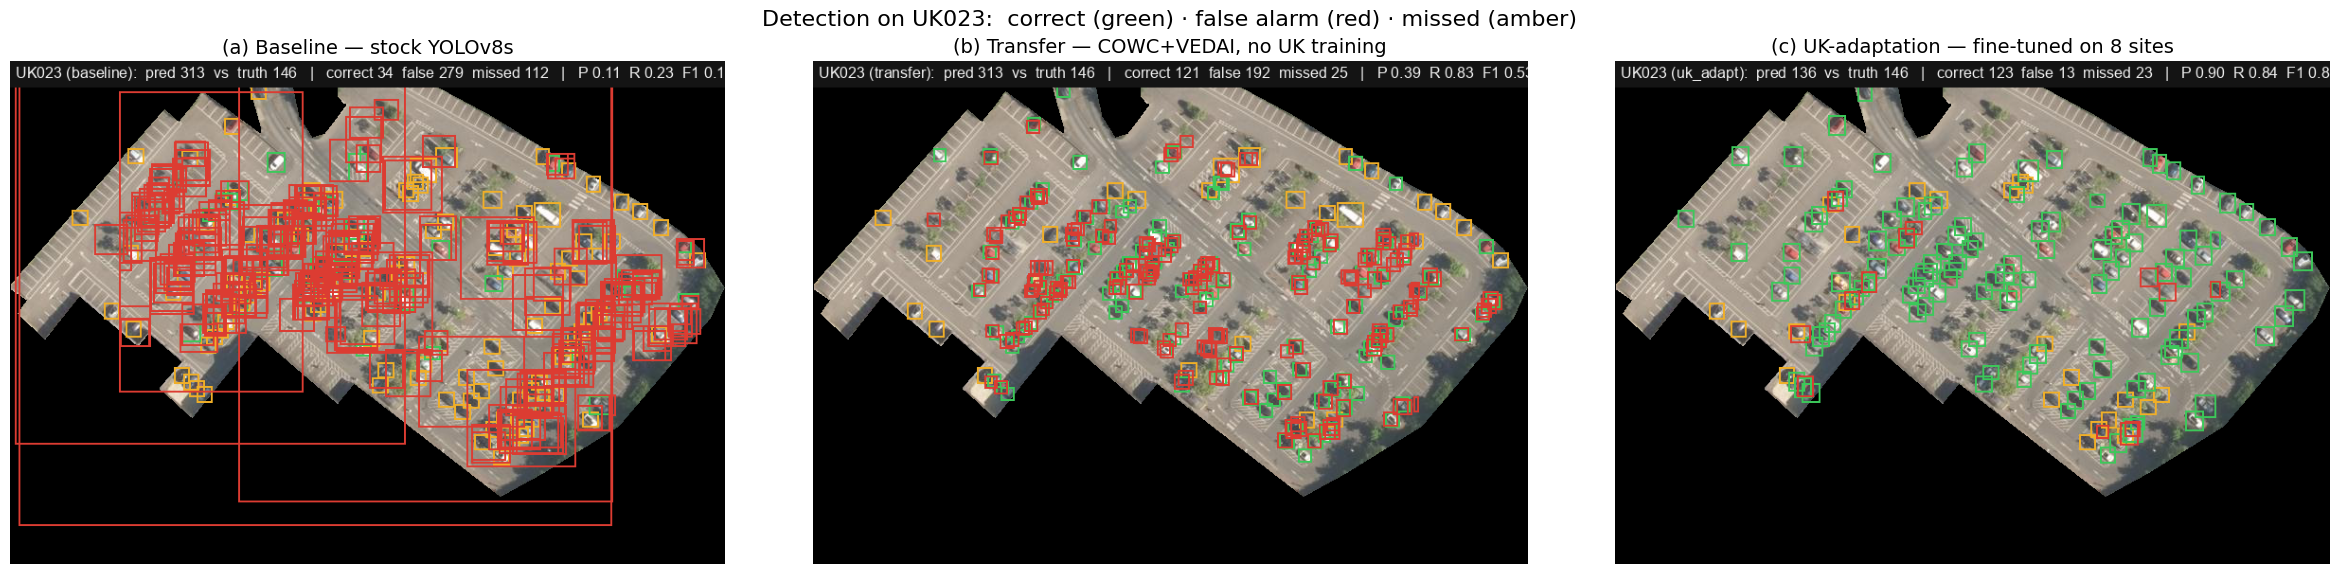

In [3]:
import numpy as np, matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

site = "UK023"
pred_dir = Path("outputs/figures/predictions")
panels = [
    (pred_dir / f"{site}_baseline.png", "(a) Baseline — stock YOLOv8s"),
    (pred_dir / f"{site}_transfer.png", "(b) Transfer — COWC+VEDAI, no UK training"),
    (pred_dir / f"{site}_uk_adapt.png", "(c) UK-adaptation — fine-tuned on 8 sites"),
]

raw = [Image.open(p).convert("RGB") for p, _ in panels]

def bbox(im, t=8):
    a = np.asarray(im); m = a.max(2) > t
    ys, xs = np.where(m.any(1))[0], np.where(m.any(0))[0]
    return xs[0], ys[0], xs[-1] + 1, ys[-1] + 1

bs = [bbox(im) for im in raw]

# Option A: UNION bounding box with 40px padding for larger frame height
pad = 40
x0 = max(0, min(b[0] for b in bs) - pad)
y0 = max(0, min(b[1] for b in bs) - pad)
x1 = min(raw[0].width,  max(b[2] for b in bs) + pad)
y1 = min(raw[0].height, max(b[3] for b in bs) + pad)
box = (x0, y0, x1, y1)

imgs = [im.crop(box) for im in raw]

# Increase base width (fig_w) -> automatically scales panel height upward
w, h = imgs[0].size
fig_w = 24  # Increased from 18
fig_h = (fig_w / 3) * (h / w)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h), constrained_layout=True)

for ax, img, (_, label) in zip(axes, imgs, panels):
    ax.imshow(img)
    ax.set_title(label, fontsize=14)
    ax.axis("off")

fig.suptitle(f"Detection on {site}:  correct (green) · false alarm (red) · missed (amber)",
             fontsize=16)
fig.savefig(f"{site}_ladder_comparison.png", dpi=300, bbox_inches="tight")
plt.show()